### Investicinių portfelių sudarymas

In [2]:
# pasirenkamos europos akcijos
akcijos = [
    "ASML.AS",   # ASML Holding
    "SAP.DE",    # SAP
    "SIE.DE",    # Siemens
    "MC.PA",     # LVMH
    "TTE.PA",    # TotalEnergies
    "AIR.PA",    # Airbus
    "SAN.PA",    # Sanofi
    "NESN.SW",   # Nestlé
    "NOVO-B.CO", # Novo Nordisk
    "SAN.MC"     # Banco Santander 
]

print(akcijos)

['ASML.AS', 'SAP.DE', 'SIE.DE', 'MC.PA', 'TTE.PA', 'AIR.PA', 'SAN.PA', 'NESN.SW', 'NOVO-B.CO', 'SAN.MC']


In [1]:
# pasirenkamos jav akcijos
akcijos = [
    "MSFT",  # Information Technology - Microsoft
    "JPM",   # Financials - JPMorgan Chase
    "XOM",   # Energy - Exxon Mobil
    "JNJ",   # Health Care - Johnson & Johnson
    "PG",    # Consumer Staples - Procter & Gamble
    "HD",    # Consumer Discretionary - Home Depot
    "CAT",   # Industrials - Caterpillar
    "LIN",   # Materials - Linde
    "AMT",   # Real Estate - American Tower
    "GOOGL"  # Communication Services - Alphabet
]
print(akcijos)

['MSFT', 'JPM', 'XOM', 'JNJ', 'PG', 'HD', 'CAT', 'LIN', 'AMT', 'GOOGL']


In [4]:
import warnings
warnings.filterwarnings("ignore", message="Timestamp\\.utcnow is deprecated")
import yfinance as yf
import pandas as pd

pradzia = "2016-01-01"
pabaiga = "2026-01-01"

duomenys = yf.download(
    akcijos,
    start=pradzia,
    end=pabaiga,
    interval="1d",
    progress=False,
    auto_adjust=True
)

kainos = duomenys["Close"].copy() # naudojamos kainos su dividendais ir akcijų padalijimais
kainos = kainos.dropna(how="all") # pašalinamos visiškai tuščios eilutės (dienos, kai nevyksta prekyba)
kainos = kainos.ffill() # trukstamos reikšmės užpildomos paskutine žinoma kaina
kainos = kainos.dropna(axis=1) # pašalinamos akcijos, kuriose vis dar yra trūkstamų reikšmių

print("Likusios akcijos:", len(kainos.columns))
print("Akcijų sąrašas:", kainos.columns.tolist())

padalijimas = int(len(kainos) * 0.8) # 80% duomenų treniravimui, 20% testavimui
train_kainos = kainos.iloc[:padalijimas]
test_kainos = kainos.iloc[padalijimas:]

# skaičiuojamos dieninės grąžos
train_grazos = train_kainos.pct_change().dropna()
test_grazos = test_kainos.pct_change().dropna()
print("Train grąžų pirmos 5 eilutės:")
print(train_grazos.head())
print("\nTest grąžų pirmos 5 eilutės:")
print(test_grazos.head())
print("\nTrain grąžų dydis:", train_grazos.shape)
print("Test grąžų dydis:", test_grazos.shape)

# metinės vidutinės grąžos ir kovariacijų matrica
vid_grazos = train_grazos.mean() * 252
kov_matrica = train_grazos.cov() * 252
print("\nMetinės vidutinės grąžos:")
print(vid_grazos)
print("\nKovariacijų matrica:")
print(kov_matrica)

Likusios akcijos: 10
Akcijų sąrašas: ['AIR.PA', 'ASML.AS', 'MC.PA', 'NESN.SW', 'NOVO-B.CO', 'SAN.MC', 'SAN.PA', 'SAP.DE', 'SIE.DE', 'TTE.PA']
Train grąžų pirmos 5 eilutės:
Ticker        AIR.PA   ASML.AS     MC.PA   NESN.SW  NOVO-B.CO    SAN.MC  \
Date                                                                      
2016-01-05  0.020210  0.007867  0.001796  0.003399   0.026149 -0.008603   
2016-01-06 -0.013207 -0.023293 -0.019720 -0.010163  -0.013360 -0.032199   
2016-01-07 -0.020075 -0.023341 -0.000731 -0.023272  -0.028335 -0.020529   
2016-01-08 -0.021319 -0.042213 -0.009151 -0.014716  -0.017807 -0.026981   
2016-01-11 -0.011062  0.026444 -0.001108 -0.000711  -0.016290  0.009903   

Ticker        SAN.PA    SAP.DE    SIE.DE    TTE.PA  
Date                                                
2016-01-05  0.011860  0.012043  0.006313 -0.009130  
2016-01-06 -0.013505  0.008680 -0.003950 -0.009588  
2016-01-07 -0.010849 -0.009854 -0.019130 -0.024265  
2016-01-08 -0.025068 -0.004065 -0.006

In [5]:
import numpy as np
from scipy.optimize import minimize

nerizikingu_palukanu_norma = 0.02  # norma reikalinga sarpo rodiklio skaiciavimui
aktyvu_skaicius = len(vid_grazos)

def portfelio_rodikliai(svoriai, vid_grazos, kov_matrica):
    portfelio_graza = np.sum(svoriai * vid_grazos)
    portfelio_rizika = np.sqrt(np.dot(svoriai.T, np.dot(kov_matrica, svoriai)))
    return portfelio_graza, portfelio_rizika

def neigiamas_sharpe(svoriai, vid_grazos, kov_matrica, nerizikingu_palukanu_norma):
    portfelio_graza, portfelio_rizika = portfelio_rodikliai(svoriai, vid_grazos, kov_matrica)
    return -(portfelio_graza - nerizikingu_palukanu_norma) / portfelio_rizika

apribojimai = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})
ribos = tuple((0, 1) for _ in range(aktyvu_skaicius))
pradiniai_svoriai = np.ones(aktyvu_skaicius) / aktyvu_skaicius

# optimizacija su minimizavimo funkcija, kuri grąžina neigiamą Sharpe rodiklį
optimizavimo_rezultatas = minimize(
    neigiamas_sharpe,
    pradiniai_svoriai,
    args=(vid_grazos, kov_matrica, nerizikingu_palukanu_norma),
    method='SLSQP',
    bounds=ribos,
    constraints=apribojimai
)

optimalus_svoriai = optimizavimo_rezultatas.x
optimali_graza, optimali_rizika = portfelio_rodikliai(optimalus_svoriai, vid_grazos, kov_matrica)
optimalus_sharpe = (optimali_graza - nerizikingu_palukanu_norma) / optimali_rizika

print("\n=== Maksimalaus Sharpe rodiklio portfelis ===")
svoriai_lentele = pd.DataFrame({
    "Akcija": vid_grazos.index,
    "Svoris": optimalus_svoriai.round(4)
})
print("\nOptimalūs svoriai:")
print(svoriai_lentele)
print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {optimali_graza:.4f}")
print(f"Metinė rizika (std): {optimali_rizika:.4f}")
print(f"Sharpe santykis: {optimalus_sharpe:.4f}")

# testavimas su testiniais duomenimis
testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252
testo_graza, testo_rizika = portfelio_rodikliai(
    optimalus_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)
testo_sharpe = (testo_graza - nerizikingu_palukanu_norma) / testo_rizika


testo_portfelio_dienos_grazos = test_grazos.dot(optimalus_svoriai)
kaupiamoji_graza = (1 + testo_portfelio_dienos_grazos).cumprod() # kumuliatyvi grąža
bendra_kaupiamoji_graza = kaupiamoji_graza.iloc[-1] - 1

ankstesnis_pikas = kaupiamoji_graza.cummax()
nuosmukis = (kaupiamoji_graza - ankstesnis_pikas) / ankstesnis_pikas
maksimalus_nuosmukis = nuosmukis.min()

tiksline_dienos_graza = nerizikingu_palukanu_norma / 252
neigiami_nukrypimai = testo_portfelio_dienos_grazos[testo_portfelio_dienos_grazos < tiksline_dienos_graza] - tiksline_dienos_graza
downside_rizika = np.sqrt((neigiami_nukrypimai ** 2).mean()) * np.sqrt(252)

print("\n=== Ne imties testas ===")
print(f"Metinė grąža: {testo_graza:.4f}")
print(f"Metinė rizika: {testo_rizika:.4f}")
print(f"Sharpe santykis: {testo_sharpe:.4f}")
print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza:.4f}")
print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis:.4f}")


=== Maksimalaus Sharpe rodiklio portfelis ===

Optimalūs svoriai:
      Akcija  Svoris
0     AIR.PA  0.0000
1    ASML.AS  0.3555
2      MC.PA  0.2991
3    NESN.SW  0.0000
4  NOVO-B.CO  0.3453
5     SAN.MC  0.0000
6     SAN.PA  0.0000
7     SAP.DE  0.0000
8     SIE.DE  0.0000
9     TTE.PA  0.0000

Portfelio rodikliai:
Metinė grąža: 0.2654
Metinė rizika (std): 0.2145
Sharpe santykis: 1.1442

=== Ne imties testas ===
Metinė grąža: -0.0044
Metinė rizika: 0.2670
Sharpe santykis: -0.0915
Kaupiamoji grąža: -0.0787
Maksimalus nuosmukis: -0.4901


In [6]:
# minimalios rizikos portfelis
import numpy as np
from scipy.optimize import minimize

aktyvu_skaicius = len(vid_grazos)

def portfelio_rizika(svoriai, kov_matrica):
    return np.sqrt(np.dot(svoriai.T, np.dot(kov_matrica, svoriai)))

# apribojimas: svorių suma turi būti lygi 1
apribojimai = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})

# svoriai tarp 0 ir 1
ribos = tuple((0, 1) for _ in range(aktyvu_skaicius))
# pradinis spėjimas - vienodi svoriai
pradiniai_svoriai = np.ones(aktyvu_skaicius) / aktyvu_skaicius

# optimizacija
minimalios_dispersijos_rezultatas = minimize(
    portfelio_rizika,
    pradiniai_svoriai,
    args=(kov_matrica,),
    method='SLSQP',
    bounds=ribos,
    constraints=apribojimai
)

minimalios_dispersijos_svoriai = minimalios_dispersijos_rezultatas.x

# treniravimo rodikliai
minimalios_dispersijos_graza, minimalios_dispersijos_rizika = portfelio_rodikliai(
    minimalios_dispersijos_svoriai,
    vid_grazos,
    kov_matrica
)
minimalios_dispersijos_sharpe = (
    minimalios_dispersijos_graza - nerizikingu_palukanu_norma
) / minimalios_dispersijos_rizika

print("\n=== Minimalios rizikos portfelis treniravimui ===")
svoriai_lentele_md = pd.DataFrame({
    "Akcija": vid_grazos.index,
    "Svoris": minimalios_dispersijos_svoriai.round(4)
})

print("\nOptimalūs svoriai:")
print(svoriai_lentele_md)
print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {minimalios_dispersijos_graza:.4f}")
print(f"Metinė rizika: {minimalios_dispersijos_rizika:.4f}")
print(f"Sharpe santykis: {minimalios_dispersijos_sharpe:.4f}")

# bandymas su testiniais duomenimis
testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252
testo_graza_md, testo_rizika_md = portfelio_rodikliai(
    minimalios_dispersijos_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)
testo_sharpe_md = (
    testo_graza_md - nerizikingu_palukanu_norma
) / testo_rizika_md

# papildomi testavimo rodikliai
testo_portfelio_dienos_grazos_md = test_grazos.dot(minimalios_dispersijos_svoriai)

kaupiamoji_graza_md = (1 + testo_portfelio_dienos_grazos_md).cumprod()
bendra_kaupiamoji_graza_md = kaupiamoji_graza_md.iloc[-1] - 1

ankstesnis_pikas_md = kaupiamoji_graza_md.cummax()
nuosmukis_md = (kaupiamoji_graza_md - ankstesnis_pikas_md) / ankstesnis_pikas_md
maksimalus_nuosmukis_md = nuosmukis_md.min()

print("\n=== Minimalios rizikos portfelis testavimui ===")
print(f"Metinė grąža: {testo_graza_md:.4f}")
print(f"Metinė rizika: {testo_rizika_md:.4f}")
print(f"Sharpe santykis: {testo_sharpe_md:.4f}")
print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza_md:.4f}")
print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis_md:.4f}")


=== Minimalios rizikos portfelis treniravimui ===

Optimalūs svoriai:
      Akcija  Svoris
0     AIR.PA  0.0000
1    ASML.AS  0.0000
2      MC.PA  0.0000
3    NESN.SW  0.5756
4  NOVO-B.CO  0.0942
5     SAN.MC  0.0050
6     SAN.PA  0.1378
7     SAP.DE  0.0806
8     SIE.DE  0.0131
9     TTE.PA  0.0936

Portfelio rodikliai:
Metinė grąža: 0.0998
Metinė rizika: 0.1391
Sharpe santykis: 0.5740

=== Minimalios rizikos portfelis testavimui ===
Metinė grąža: -0.0240
Metinė rizika: 0.1414
Sharpe santykis: -0.3113
Kaupiamoji grąža: -0.0668
Maksimalus nuosmukis: -0.2177


In [7]:
# lygiasvoris portfelis

aktyvu_skaicius = len(vid_grazos)

lygus_svoriai = np.ones(aktyvu_skaicius) / aktyvu_skaicius

# treniravimo rodikliai
lygiasvorio_graza, lygiasvorio_rizika = portfelio_rodikliai(
    lygus_svoriai,
    vid_grazos,
    kov_matrica
)

lygiasvorio_sharpe = (
    lygiasvorio_graza - nerizikingu_palukanu_norma
) / lygiasvorio_rizika

print("\n=== Lygiasvoris portfelis treniravimui ===")

svoriai_lentele_lv = pd.DataFrame({
    "Akcija": vid_grazos.index,
    "Svoris": lygus_svoriai.round(4)
})

print("\nOptimalūs svoriai (lygūs):")
print(svoriai_lentele_lv)

print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {lygiasvorio_graza:.4f}")
print(f"Metinė rizika: {lygiasvorio_rizika:.4f}")
print(f"Sharpe santykis: {lygiasvorio_sharpe:.4f}")

# lygiasvoris portfelis testavimui
testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252

testo_graza_lv, testo_rizika_lv = portfelio_rodikliai(
    lygus_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)

testo_sharpe_lv = (
    testo_graza_lv - nerizikingu_palukanu_norma
) / testo_rizika_lv

# papildomi testavimo rodikliai
testo_portfelio_dienos_grazos_lv = test_grazos.dot(lygus_svoriai)

kaupiamoji_graza_lv = (1 + testo_portfelio_dienos_grazos_lv).cumprod()
bendra_kaupiamoji_graza_lv = kaupiamoji_graza_lv.iloc[-1] - 1

ankstesnis_pikas_lv = kaupiamoji_graza_lv.cummax()
nuosmukis_lv = (kaupiamoji_graza_lv - ankstesnis_pikas_lv) / ankstesnis_pikas_lv
maksimalus_nuosmukis_lv = nuosmukis_lv.min()

print("\n=== Lygiasvoris portfelis testavimui ===")
print(f"Metinė grąža: {testo_graza_lv:.4f}")
print(f"Metinė rizika: {testo_rizika_lv:.4f}")
print(f"Sharpe santykis: {testo_sharpe_lv:.4f}")
print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza_lv:.4f}")
print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis_lv:.4f}")


=== Lygiasvoris portfelis treniravimui ===

Optimalūs svoriai (lygūs):
      Akcija  Svoris
0     AIR.PA     0.1
1    ASML.AS     0.1
2      MC.PA     0.1
3    NESN.SW     0.1
4  NOVO-B.CO     0.1
5     SAN.MC     0.1
6     SAN.PA     0.1
7     SAP.DE     0.1
8     SIE.DE     0.1
9     TTE.PA     0.1

Portfelio rodikliai:
Metinė grąža: 0.1656
Metinė rizika: 0.1839
Sharpe santykis: 0.7918

=== Lygiasvoris portfelis testavimui ===
Metinė grąža: 0.1240
Metinė rizika: 0.1631
Sharpe santykis: 0.6377
Kaupiamoji grąža: 0.2527
Maksimalus nuosmukis: -0.2061



=== Simuliacinis portfelis: didžiausia grąža prie ribotos rizikos ===
Metinė grąža: 0.2290
Metinė rizika: 0.1953
Sharpe santykis: 1.0704

Simuliacinio portfelio svoriai:
      Akcija    Svoris
0     AIR.PA  0.010902
1    ASML.AS  0.293084
2      MC.PA  0.222347
3    NESN.SW  0.096333
4  NOVO-B.CO  0.190489
5     SAN.MC  0.004517
6     SAN.PA  0.002370
7     SAP.DE  0.048148
8     SIE.DE  0.061583
9     TTE.PA  0.070227

=== Simuliacinis portfelis testavimui ===
Metinė grąža: 0.0483
Metinė rizika: 0.2132
Sharpe santykis: 0.1329
Kaupiamoji grąža: 0.0534
Maksimalus nuosmukis: -0.3485


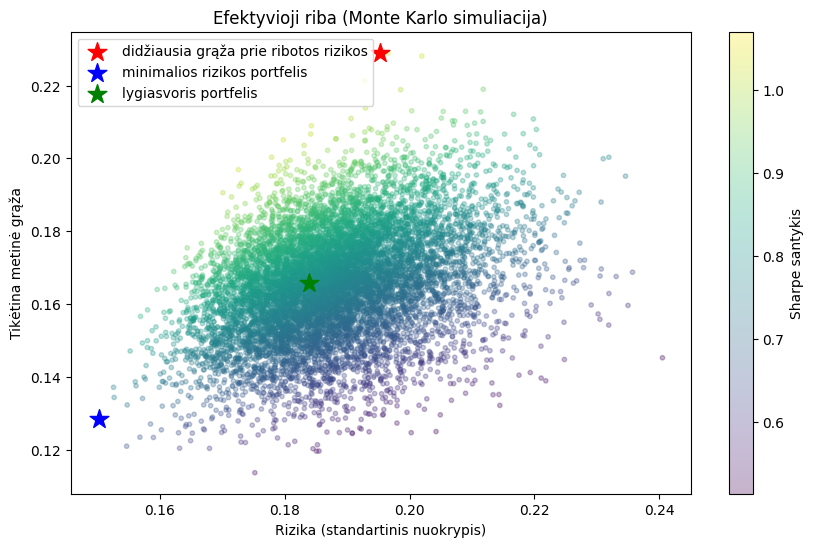

In [8]:
import matplotlib.pyplot as plt

# simuliacinis portfelis
simuliaciju_skaicius = 10000

# nustatoma maksimali leistina rizika
maksimali_leistina_rizika = 0.20

rezultatai = np.zeros((3, simuliaciju_skaicius))
visi_svoriai = []

for i in range(simuliaciju_skaicius):
    # atsitiktiniai svoriai
    svoriai = np.random.random(aktyvu_skaicius)
    svoriai /= np.sum(svoriai)
    visi_svoriai.append(svoriai)

    portfelio_graza, portfelio_rizika = portfelio_rodikliai(
        svoriai,
        vid_grazos,
        kov_matrica
    )

    sharpe_santykis = (
        portfelio_graza - nerizikingu_palukanu_norma
    ) / portfelio_rizika

    rezultatai[0, i] = portfelio_graza
    rezultatai[1, i] = portfelio_rizika
    rezultatai[2, i] = sharpe_santykis

# portfeliai, kurių rizika neviršija nustatytos ribos
galimi_indeksai = np.where(rezultatai[1, :] <= maksimali_leistina_rizika)[0]

if len(galimi_indeksai) > 0:
    geriausias_galimas_indeksas = galimi_indeksai[np.argmax(rezultatai[0, galimi_indeksai])]
else:
    geriausias_galimas_indeksas = np.argmin(rezultatai[1, :])

simuliacinio_portfelio_graza = rezultatai[0, geriausias_galimas_indeksas]
simuliacinio_portfelio_rizika = rezultatai[1, geriausias_galimas_indeksas]
simuliacinio_portfelio_sharpe = rezultatai[2, geriausias_galimas_indeksas]
simuliacinio_portfelio_svoriai = visi_svoriai[geriausias_galimas_indeksas]

# minimalios dispersijos portfelis iš simuliacijų
minimalios_rizikos_indeksas = np.argmin(rezultatai[1, :])
minimalios_rizikos_graza = rezultatai[0, minimalios_rizikos_indeksas]
minimalios_rizikos_rizika = rezultatai[1, minimalios_rizikos_indeksas]
minimalios_rizikos_sharpe = rezultatai[2, minimalios_rizikos_indeksas]
minimalios_rizikos_svoriai = visi_svoriai[minimalios_rizikos_indeksas]

print("\n=== Simuliacinis portfelis: didžiausia grąža prie ribotos rizikos ===")
print(f"Metinė grąža: {simuliacinio_portfelio_graza:.4f}")
print(f"Metinė rizika: {simuliacinio_portfelio_rizika:.4f}")
print(f"Sharpe santykis: {simuliacinio_portfelio_sharpe:.4f}")

simuliacinio_portfelio_lentele = pd.DataFrame({
    "Akcija": vid_grazos.index,
    "Svoris": simuliacinio_portfelio_svoriai
})

print("\nSimuliacinio portfelio svoriai:")
print(simuliacinio_portfelio_lentele)

# simuliacinis portfelis testavimui
testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252

testo_graza_sim, testo_rizika_sim = portfelio_rodikliai(
    simuliacinio_portfelio_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)

testo_sharpe_sim = (
    testo_graza_sim - nerizikingu_palukanu_norma
) / testo_rizika_sim

# papildomi testavimo rodikliai
testo_portfelio_dienos_grazos_sim = test_grazos.dot(simuliacinio_portfelio_svoriai)

kaupiamoji_graza_sim = (1 + testo_portfelio_dienos_grazos_sim).cumprod()
bendra_kaupiamoji_graza_sim = kaupiamoji_graza_sim.iloc[-1] - 1

ankstesnis_pikas_sim = kaupiamoji_graza_sim.cummax()
nuosmukis_sim = (kaupiamoji_graza_sim - ankstesnis_pikas_sim) / ankstesnis_pikas_sim
maksimalus_nuosmukis_sim = nuosmukis_sim.min()

print("\n=== Simuliacinis portfelis testavimui ===")
print(f"Metinė grąža: {testo_graza_sim:.4f}")
print(f"Metinė rizika: {testo_rizika_sim:.4f}")
print(f"Sharpe santykis: {testo_sharpe_sim:.4f}")
print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza_sim:.4f}")
print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis_sim:.4f}")

# efektyvios ribos grafikas
plt.figure(figsize=(10, 6))
plt.scatter(
    rezultatai[1, :],
    rezultatai[0, :],
    c=rezultatai[2, :],
    cmap='viridis',
    marker='o',
    s=10,
    alpha=0.3
)

plt.colorbar(label='Sharpe santykis')

plt.scatter(
    simuliacinio_portfelio_rizika,
    simuliacinio_portfelio_graza,
    color='r',
    marker='*',
    s=200,
    label='didžiausia grąža prie ribotos rizikos'
)

plt.scatter(
    minimalios_rizikos_rizika,
    minimalios_rizikos_graza,
    color='b',
    marker='*',
    s=200,
    label='minimalios rizikos portfelis'
)

plt.scatter(
    lygiasvorio_rizika,
    lygiasvorio_graza,
    color='g',
    marker='*',
    s=200,
    label='lygiasvoris portfelis'
)

plt.title('Efektyvioji riba (Monte Karlo simuliacija)')
plt.xlabel('Rizika (standartinis nuokrypis)')
plt.ylabel('Tikėtina metinė grąža')
plt.legend()
plt.show()

In [9]:
from skfolio.optimization import MaximumDiversification
import pandas as pd

mokymo_grazos = train_grazos

maksimalaus_diversifikavimo_modelis = MaximumDiversification()
maksimalaus_diversifikavimo_modelis.fit(mokymo_grazos)

maksimalaus_diversifikavimo_svoriai = maksimalaus_diversifikavimo_modelis.weights_

maksimalaus_diversifikavimo_lentele = pd.DataFrame({
    "Akcija": mokymo_grazos.columns,
    "Svoris": maksimalaus_diversifikavimo_svoriai.round(4)
})

print("\n=== Maksimalaus diversifikavimo portfelis treniravimui ===")
print(maksimalaus_diversifikavimo_lentele)

maksimalaus_diversifikavimo_graza, maksimalaus_diversifikavimo_rizika = portfelio_rodikliai(
    maksimalaus_diversifikavimo_svoriai,
    vid_grazos,
    kov_matrica
)

maksimalaus_diversifikavimo_sharpe = (
    maksimalaus_diversifikavimo_graza - nerizikingu_palukanu_norma
) / maksimalaus_diversifikavimo_rizika

print("\nTreniravimo rodikliai:")
print(f"Metinė grąža: {maksimalaus_diversifikavimo_graza:.4f}")
print(f"Metinė rizika: {maksimalaus_diversifikavimo_rizika:.4f}")
print(f"Sharpe santykis: {maksimalaus_diversifikavimo_sharpe:.4f}")

testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252

testo_graza_mdiv, testo_rizika_mdiv = portfelio_rodikliai(
    maksimalaus_diversifikavimo_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)

testo_sharpe_mdiv = (
    testo_graza_mdiv - nerizikingu_palukanu_norma
) / testo_rizika_mdiv

# papildomi testavimo rodikliai
testo_portfelio_dienos_grazos_mdiv = test_grazos.dot(maksimalaus_diversifikavimo_svoriai)

kaupiamoji_graza_mdiv = (1 + testo_portfelio_dienos_grazos_mdiv).cumprod()
bendra_kaupiamoji_graza_mdiv = kaupiamoji_graza_mdiv.iloc[-1] - 1

ankstesnis_pikas_mdiv = kaupiamoji_graza_mdiv.cummax()
nuosmukis_mdiv = (kaupiamoji_graza_mdiv - ankstesnis_pikas_mdiv) / ankstesnis_pikas_mdiv
maksimalus_nuosmukis_mdiv = nuosmukis_mdiv.min()

print("\n Maksimalaus diversifikavimo portfelis testavimui ")
print(f"Metinė grąža: {testo_graza_mdiv:.4f}")
print(f"Metinė rizika: {testo_rizika_mdiv:.4f}")
print(f"Sharpe santykis: {testo_sharpe_mdiv:.4f}")
print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza_mdiv:.4f}")
print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis_mdiv:.4f}")


=== Maksimalaus diversifikavimo portfelis treniravimui ===
      Akcija  Svoris
0     AIR.PA  0.0592
1    ASML.AS  0.0878
2      MC.PA  0.0000
3    NESN.SW  0.2379
4  NOVO-B.CO  0.2181
5     SAN.MC  0.0967
6     SAN.PA  0.1366
7     SAP.DE  0.0595
8     SIE.DE  0.0000
9     TTE.PA  0.1043

Treniravimo rodikliai:
Metinė grąža: 0.1452
Metinė rizika: 0.1584
Sharpe santykis: 0.7904

 Maksimalaus diversifikavimo portfelis testavimui 
Metinė grąža: 0.0398
Metinė rizika: 0.1611
Sharpe santykis: 0.1229
Kaupiamoji grąža: 0.0560
Maksimalus nuosmukis: -0.2372


In [10]:
from skfolio.optimization import RiskBudgeting
from skfolio.measures import RiskMeasure
import pandas as pd

rizikos_pariteto_modelis = RiskBudgeting(
    risk_measure=RiskMeasure.VARIANCE,
    portfolio_params=dict(name="Rizikos paritetas")
)

rizikos_pariteto_modelis.fit(train_grazos)
rizikos_pariteto_svoriai = rizikos_pariteto_modelis.weights_

rizikos_pariteto_lentele = pd.DataFrame({
    "Akcija": train_grazos.columns,
    "Svoris": rizikos_pariteto_svoriai
})

print("\n=== Rizikos pariteto portfelis treniravimui ===")
print(rizikos_pariteto_lentele)

rizikos_pariteto_graza, rizikos_pariteto_rizika = portfelio_rodikliai(
    rizikos_pariteto_svoriai.round(4),
    vid_grazos,
    kov_matrica
)

rizikos_pariteto_sharpe = (
    rizikos_pariteto_graza - nerizikingu_palukanu_norma
) / rizikos_pariteto_rizika

print("\nTreniravimo rodikliai:")
print(f"Metinė grąža: {rizikos_pariteto_graza:.4f}")
print(f"Metinė rizika: {rizikos_pariteto_rizika:.4f}")
print(f"Sharpe santykis: {rizikos_pariteto_sharpe:.4f}")

testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252

testo_graza_rp, testo_rizika_rp = portfelio_rodikliai(
    rizikos_pariteto_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)

testo_sharpe_rp = (
    testo_graza_rp - nerizikingu_palukanu_norma
) / testo_rizika_rp

# papildomi testavimo rodikliai
testo_portfelio_dienos_grazos_rp = test_grazos.dot(rizikos_pariteto_svoriai)

kaupiamoji_graza_rp = (1 + testo_portfelio_dienos_grazos_rp).cumprod()
bendra_kaupiamoji_graza_rp = kaupiamoji_graza_rp.iloc[-1] - 1

ankstesnis_pikas_rp = kaupiamoji_graza_rp.cummax()
nuosmukis_rp = (kaupiamoji_graza_rp - ankstesnis_pikas_rp) / ankstesnis_pikas_rp
maksimalus_nuosmukis_rp = nuosmukis_rp.min()

print("\n=== Rizikos pariteto portfelis testavimui ===")
print(f"Metinė grąža: {testo_graza_rp:.4f}")
print(f"Metinė rizika: {testo_rizika_rp:.4f}")
print(f"Sharpe santykis: {testo_sharpe_rp:.4f}")
print(f"Kaupiamoji grąža: {bendra_kaupiamoji_graza_rp:.4f}")
print(f"Maksimalus nuosmukis: {maksimalus_nuosmukis_rp:.4f}")


=== Rizikos pariteto portfelis treniravimui ===
      Akcija    Svoris
0     AIR.PA  0.066055
1    ASML.AS  0.076603
2      MC.PA  0.082739
3    NESN.SW  0.181245
4  NOVO-B.CO  0.126458
5     SAN.MC  0.070851
6     SAN.PA  0.130940
7     SAP.DE  0.095745
8     SIE.DE  0.080236
9     TTE.PA  0.089128

Treniravimo rodikliai:
Metinė grąža: 0.1535
Metinė rizika: 0.1659
Sharpe santykis: 0.8047

=== Rizikos pariteto portfelis testavimui ===
Metinė grąža: 0.0781
Metinė rizika: 0.1531
Sharpe santykis: 0.3798
Kaupiamoji grąža: 0.1448
Maksimalus nuosmukis: -0.1990



=== Portfelių palyginimo lentelė ===
           Portfelis  Metinė grąža %  Metinė rizika %  Sharpe  \
0       Maks. Sharpe           -0.44            26.70   -0.09   
1        Min. rizika           -2.40            14.14   -0.31   
2        Lygiasvoris           12.40            16.31    0.64   
3       Simuliacinis            4.83            21.32    0.13   
4      Maks. divers.            3.98            16.11    0.12   
5  Rizikos paritetas            7.81            15.31    0.38   

   Kaupiamoji grąža %  Maksimalus nuosmukis %  
0               -7.87                  -49.01  
1               -6.68                  -21.77  
2               25.27                  -20.61  
3                5.34                  -34.85  
4                5.60                  -23.72  
5               14.48                  -19.90  


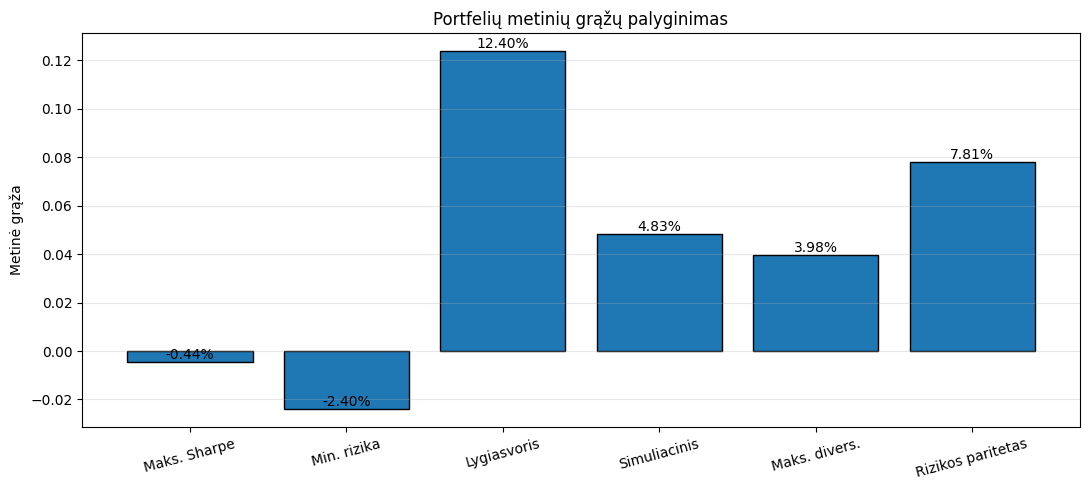

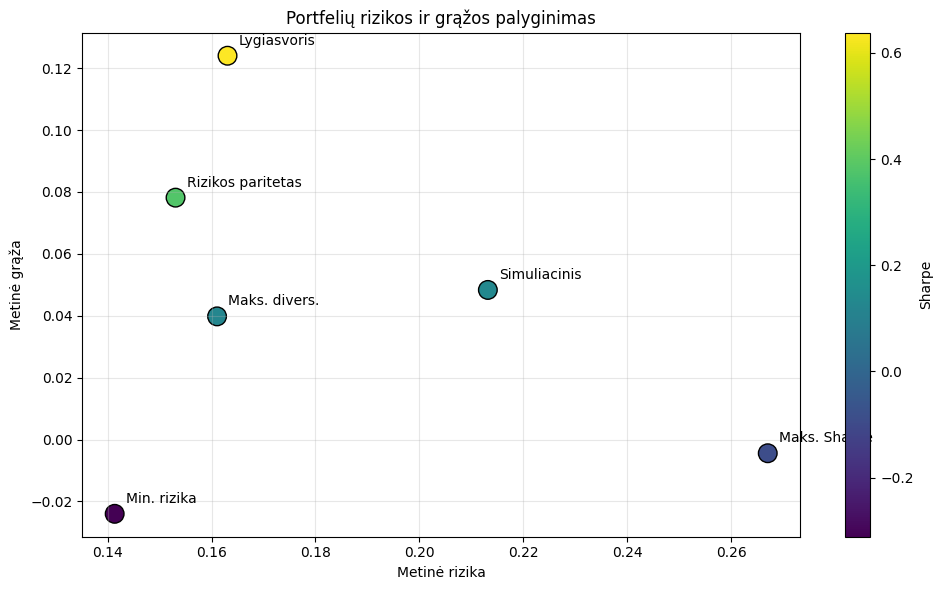

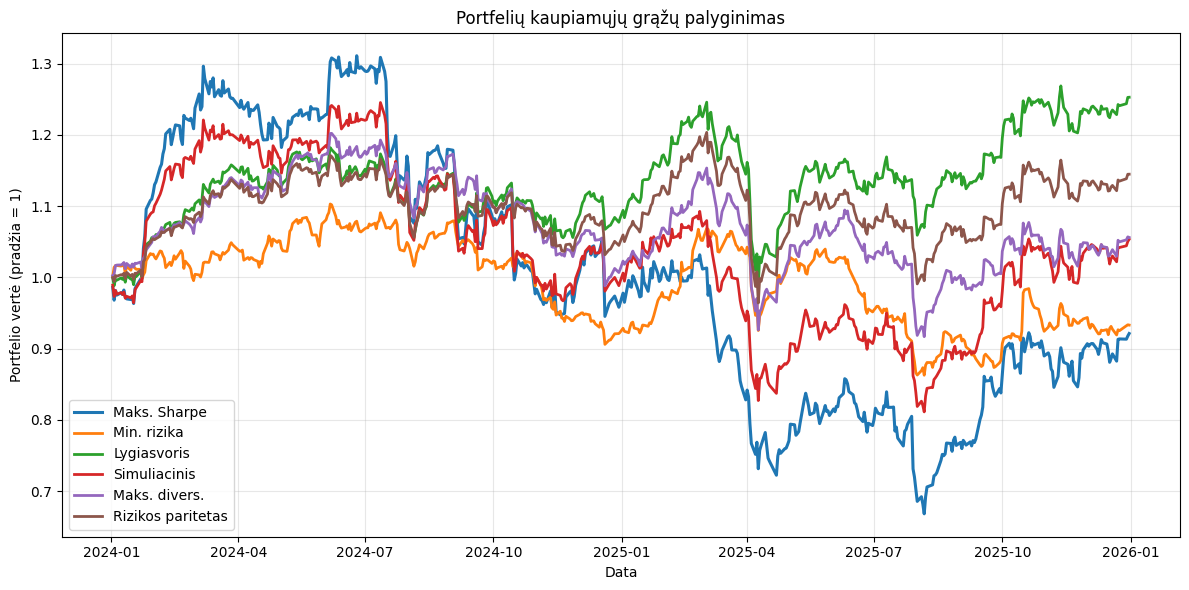

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# kaupiamosios grąžos kreivės
kaupiamoji_max_sharpe = (1 + testo_portfelio_dienos_grazos).cumprod()
kaupiamoji_md = (1 + testo_portfelio_dienos_grazos_md).cumprod()
kaupiamoji_lv = (1 + testo_portfelio_dienos_grazos_lv).cumprod()
kaupiamoji_sim = (1 + testo_portfelio_dienos_grazos_sim).cumprod()
kaupiamoji_mdiv = (1 + testo_portfelio_dienos_grazos_mdiv).cumprod()
kaupiamoji_rp = (1 + testo_portfelio_dienos_grazos_rp).cumprod()

# bendros kaupiamosios grąžos
bendra_kaupiamoji_graza = kaupiamoji_max_sharpe.iloc[-1] - 1
bendra_kaupiamoji_graza_md = kaupiamoji_md.iloc[-1] - 1
bendra_kaupiamoji_graza_lv = kaupiamoji_lv.iloc[-1] - 1
bendra_kaupiamoji_graza_sim = kaupiamoji_sim.iloc[-1] - 1
bendra_kaupiamoji_graza_mdiv = kaupiamoji_mdiv.iloc[-1] - 1
bendra_kaupiamoji_graza_rp = kaupiamoji_rp.iloc[-1] - 1

# maksimalūs nuosmukiai
maksimalus_nuosmukis = ((kaupiamoji_max_sharpe - kaupiamoji_max_sharpe.cummax()) / kaupiamoji_max_sharpe.cummax()).min()
maksimalus_nuosmukis_md = ((kaupiamoji_md - kaupiamoji_md.cummax()) / kaupiamoji_md.cummax()).min()
maksimalus_nuosmukis_lv = ((kaupiamoji_lv - kaupiamoji_lv.cummax()) / kaupiamoji_lv.cummax()).min()
maksimalus_nuosmukis_sim = ((kaupiamoji_sim - kaupiamoji_sim.cummax()) / kaupiamoji_sim.cummax()).min()
maksimalus_nuosmukis_mdiv = ((kaupiamoji_mdiv - kaupiamoji_mdiv.cummax()) / kaupiamoji_mdiv.cummax()).min()
maksimalus_nuosmukis_rp = ((kaupiamoji_rp - kaupiamoji_rp.cummax()) / kaupiamoji_rp.cummax()).min()

pavadinimai = [
    "Maks. Sharpe",
    "Min. rizika",
    "Lygiasvoris",
    "Simuliacinis",
    "Maks. divers.",
    "Rizikos paritetas"
]

metine_graza = [
    testo_graza,
    testo_graza_md,
    testo_graza_lv,
    testo_graza_sim,
    testo_graza_mdiv,
    testo_graza_rp
]

metine_rizika = [
    testo_rizika,
    testo_rizika_md,
    testo_rizika_lv,
    testo_rizika_sim,
    testo_rizika_mdiv,
    testo_rizika_rp
]

sharpe = [
    testo_sharpe,
    testo_sharpe_md,
    testo_sharpe_lv,
    testo_sharpe_sim,
    testo_sharpe_mdiv,
    testo_sharpe_rp
]

kaupiamoji_graza = [
    bendra_kaupiamoji_graza,
    bendra_kaupiamoji_graza_md,
    bendra_kaupiamoji_graza_lv,
    bendra_kaupiamoji_graza_sim,
    bendra_kaupiamoji_graza_mdiv,
    bendra_kaupiamoji_graza_rp
]

maks_nuosmukis = [
    maksimalus_nuosmukis,
    maksimalus_nuosmukis_md,
    maksimalus_nuosmukis_lv,
    maksimalus_nuosmukis_sim,
    maksimalus_nuosmukis_mdiv,
    maksimalus_nuosmukis_rp
]

rezultatu_lentele = pd.DataFrame({
    "Portfelis": pavadinimai,
    "Metinė grąža": metine_graza,
    "Metinė rizika": metine_rizika,
    "Sharpe": sharpe,
    "Kaupiamoji grąža": kaupiamoji_graza,
    "Maksimalus nuosmukis": maks_nuosmukis
})

rezultatu_lentele["Metinė grąža %"] = rezultatu_lentele["Metinė grąža"] * 100
rezultatu_lentele["Metinė rizika %"] = rezultatu_lentele["Metinė rizika"] * 100
rezultatu_lentele["Kaupiamoji grąža %"] = rezultatu_lentele["Kaupiamoji grąža"] * 100
rezultatu_lentele["Maksimalus nuosmukis %"] = rezultatu_lentele["Maksimalus nuosmukis"] * 100

print("\n=== Portfelių palyginimo lentelė ===")
print(
    rezultatu_lentele[
        [
            "Portfelis",
            "Metinė grąža %",
            "Metinė rizika %",
            "Sharpe",
            "Kaupiamoji grąža %",
            "Maksimalus nuosmukis %"
        ]
    ].round(2)
)

# stulpelinė metinių grąžų diagrama
plt.figure(figsize=(11, 5))
plt.bar(pavadinimai, metine_graza, edgecolor="black")
plt.ylabel("Metinė grąža")
plt.title("Portfelių metinių grąžų palyginimas")
plt.grid(axis="y", alpha=0.3)

for i in range(len(pavadinimai)):
    plt.text(i, metine_graza[i], f"{metine_graza[i]*100:.2f}%", ha="center", va="bottom")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# rizikos ir grąžos diagrama
plt.figure(figsize=(10, 6))
taskai = plt.scatter(metine_rizika, metine_graza, c=sharpe, cmap="viridis", s=180, edgecolors="black")

for i in range(len(pavadinimai)):
    plt.annotate(
        pavadinimai[i],
        (metine_rizika[i], metine_graza[i]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Metinė rizika")
plt.ylabel("Metinė grąža")
plt.title("Portfelių rizikos ir grąžos palyginimas")
plt.grid(alpha=0.3)
plt.colorbar(taskai, label="Sharpe")
plt.tight_layout()
plt.show()

# kaupiamųjų grąžų grafikas
plt.figure(figsize=(12, 6))

plt.plot(kaupiamoji_max_sharpe.index, kaupiamoji_max_sharpe, linewidth=2.2, label="Maks. Sharpe")
plt.plot(kaupiamoji_md.index, kaupiamoji_md, linewidth=2.0, label="Min. rizika")
plt.plot(kaupiamoji_lv.index, kaupiamoji_lv, linewidth=2.0, label="Lygiasvoris")
plt.plot(kaupiamoji_sim.index, kaupiamoji_sim, linewidth=2.0, label="Simuliacinis")
plt.plot(kaupiamoji_mdiv.index, kaupiamoji_mdiv, linewidth=2.0, label="Maks. divers.")
plt.plot(kaupiamoji_rp.index, kaupiamoji_rp, linewidth=2.0, label="Rizikos paritetas")

plt.title("Portfelių kaupiamųjų grąžų palyginimas")
plt.xlabel("Data")
plt.ylabel("Portfelio vertė (pradžia = 1)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()